In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import socket as socket

import IBDecay

In [2]:
# for developpment purpose: reload recently edited files
import importlib
mods_to_reload = [m for m in sys.modules if m.startswith('IBDecay')]
for mod in mods_to_reload:
    importlib.reload(sys.modules[mod])

In [3]:
from IBDecay.simulations import Simulator
from IBDecay.plots import Plotter
from IBDecay.expectations import Calculator, Estimator

simulator = Simulator()
plotter = Plotter()
calculator = Calculator()
estimator = Estimator()

/home/florence_pautet/bin/miniconda3/envs/work/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
c_plot = ["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154", "k"]

# Simulate RoH for a constant population

In [5]:
Ne = 500        # effective population size
nb_sim = 50     # nb of individuals to simulate
max_t = 100     # max coalescence time (generations) for simulation

In [6]:
simulator = Simulator(Ne=Ne, max_t=max_t)
df = simulator.simulate_roh(n_sim=nb_sim)
df

,lengthM,tmrca,iid,chr
0,0.029147,17.559404,0,1
1,0.040128,23.564228,0,1
2,0.021279,44.981776,0,1
3,0.061531,17.576764,0,2
4,0.045175,25.902468,0,2
...,...,...,...,...
2029,0.022680,50.125342,49,19
2030,0.020406,71.659995,49,20
2031,0.033159,96.680869,49,20
2032,0.024811,29.612521,49,21


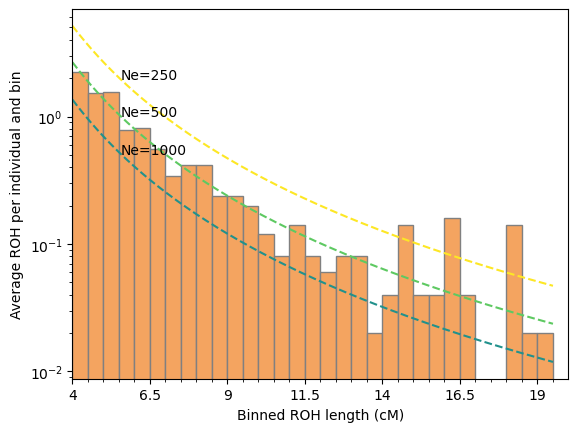

In [7]:
plotter = Plotter()
fig = plotter.plot_histo(df, bins=np.arange(0.04, 0.20, 0.005), Ne=[250, 500, 1000], nb_normalize=nb_sim, data_type="ROH")

### Estimate Ne from RoH

In [8]:
upper_bin = 0.10
Ne, Ne_CI = estimator.estimate_Ne(df["lengthM"], data_type="ROH", bin=(0.04, upper_bin), nb_observations=nb_sim)
print()

# Simulate IBD sharing accross time

In [9]:
delta_Ts = [0, 10, 20, 30, 40, 50]

### Simulate
Simulate IBD segments between an ancestral population and samples from `delta_T` generations later.

In [10]:
Ne = 500
nb_sim = 50
max_t = 100
save_path = f"simulations/Ne{Ne}_sim{nb_sim}/"

simulator = Simulator(Ne=Ne, max_t=max_t)
for delta_t in delta_Ts:
    simulator.simulate_ibd_decay(t1=delta_t, n_sim=nb_sim, ploidy=2, save_path=f"{save_path}/dt{delta_t}.csv")

/home/florence_pautet/Documents/phd/IBDecay/IBDecay/simulations.py:85: UserWarning: Output file already exists: simulations/Ne500_sim50//dt0.csv. Remove or rename it.
  warnings.warn(f"Output file already exists: {save_path}. Remove or rename it.")
/home/florence_pautet/Documents/phd/IBDecay/IBDecay/simulations.py:85: UserWarning: Output file already exists: simulations/Ne500_sim50//dt10.csv. Remove or rename it.
  warnings.warn(f"Output file already exists: {save_path}. Remove or rename it.")
/home/florence_pautet/Documents/phd/IBDecay/IBDecay/simulations.py:85: UserWarning: Output file already exists: simulations/Ne500_sim50//dt20.csv. Remove or rename it.
  warnings.warn(f"Output file already exists: {save_path}. Remove or rename it.")
/home/florence_pautet/Documents/phd/IBDecay/IBDecay/simulations.py:85: UserWarning: Output file already exists: simulations/Ne500_sim50//dt30.csv. Remove or rename it.
  warnings.warn(f"Output file already exists: {save_path}. Remove or rename it.")
/

### Plots
Estimate `delta_t` for various number of samples

In [11]:
size_subset = 50
rng = np.random.default_rng()
subsample = rng.choice(np.arange(nb_sim), size=size_subset, replace=False)

In [12]:
df_0 = pd.read_csv(f"{save_path}/dt0.csv")
df_0

,lengthM,tmrca,sim,iid1,iid2,chr,chrom_1,chrom_2
0,0.023733,46.323632,0,1,2,0,0,0
1,0.021381,46.201399,0,1,2,0,0,1
2,0.020255,79.552366,0,1,2,0,0,1
3,0.059263,7.855964,0,1,2,0,1,0
4,0.020093,45.472303,0,1,2,0,1,0
...,...,...,...,...,...,...,...,...
7802,0.028071,67.143853,49,1,2,19,1,1
7803,0.022324,98.962323,49,1,2,19,1,1
7804,0.136457,15.232253,49,1,2,20,1,1
7805,0.024307,8.830769,49,1,2,21,0,1


In [13]:
subsample

array([40, 49, 11,  0, 48, 47,  2, 22, 28, 18, 24, 36,  4,  7, 15,  6, 32,
       10, 19, 35, 44, 43, 20,  8,  3,  9, 25, 37, 23, 27, 26, 45, 29,  5,
       34, 17, 42, 33, 14, 21, 39, 46, 16, 30, 38, 31, 13, 12,  1, 41])

In [14]:
df_0[df_0['sim'].isin(subsample)].reset_index(drop=True)

,lengthM,tmrca,sim,iid1,iid2,chr,chrom_1,chrom_2
0,0.023733,46.323632,0,1,2,0,0,0
1,0.021381,46.201399,0,1,2,0,0,1
2,0.020255,79.552366,0,1,2,0,0,1
3,0.059263,7.855964,0,1,2,0,1,0
4,0.020093,45.472303,0,1,2,0,1,0
...,...,...,...,...,...,...,...,...
7802,0.028071,67.143853,49,1,2,19,1,1
7803,0.022324,98.962323,49,1,2,19,1,1
7804,0.136457,15.232253,49,1,2,20,1,1
7805,0.024307,8.830769,49,1,2,21,0,1


In [15]:
subsample

array([40, 49, 11,  0, 48, 47,  2, 22, 28, 18, 24, 36,  4,  7, 15,  6, 32,
       10, 19, 35, 44, 43, 20,  8,  3,  9, 25, 37, 23, 27, 26, 45, 29,  5,
       34, 17, 42, 33, 14, 21, 39, 46, 16, 30, 38, 31, 13, 12,  1, 41])

In [16]:
df_0 = pd.read_csv(f"{save_path}/dt0.csv")
df_0 = df_0[df_0['sim'].isin(subsample)].reset_index(drop=True)

bins = np.arange(0.04, df_0['lengthM'].max()+0.01, 0.01)
bin_mids = (bins[:-1] + bins[1:]) / 2
bin_sizes = bins[1:] - bins[:-1]

y_a = calculator.ibd_decay(delta_Ts, [1], bins, df_0["lengthM"], nb_sim)[:,0,:]

In [17]:
fig, ax = plt.subplots()
for i, dt in enumerate(delta_Ts):
    df = pd.read_csv(f"{save_path}/dt{dt}.csv", usecols=['lengthM', 'iid1', 'iid2', 'sim'])
    df = df[df['sim'].isin(subsample)].reset_index(drop=True)
    y = np.histogram(df['lengthM'], bins=bins, density=False)[0] / nb_sim
    ax.plot(bin_mids, y, color=c_plot[i], ls='', marker="o", ms=5)
    ax.plot(bin_mids, y_a[i], color=c_plot[i], ls='-', label=dt)
plt.close()

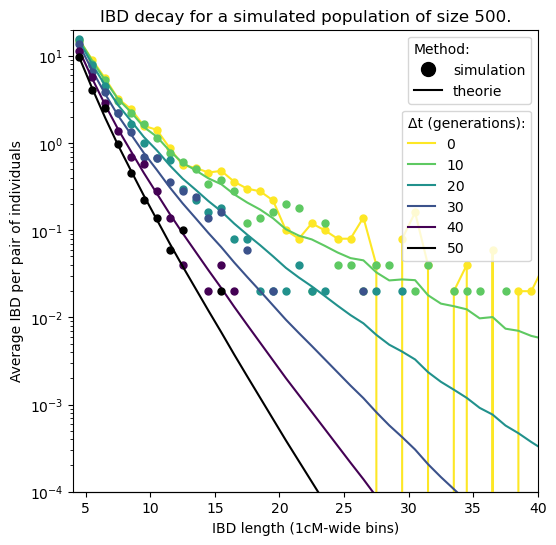

In [18]:
# New x-axis in cM
ax.get_xaxis().set_visible(False)
new_ax = ax.secondary_xaxis('bottom', functions=(lambda x: x*100, lambda x: x/100))
new_ax.set_xlabel("IBD length (1cM-wide bins)")
ax.set_ylabel("Average IBD per pair of individuals")
ax.set_yscale("log")

ax.set_xlim((0.04, 0.4))
ax.set_ylim((1e-4, 20))

fig.set_size_inches(6,6)

# Create custom legend elements
symb_1 = mlines.Line2D([], [], color='black', ls='', marker='o', markersize=10, label='simulation')
symb_2 = mlines.Line2D([], [], color='black', ls='-', label='theorie')

legend1 = ax.legend(handles=[symb_1, symb_2], loc="upper right", title="Method:", alignment="left")
# Get the position of legend1 and align legend2 below it
legend1_bbox_axes = legend1.get_window_extent().transformed(ax.transAxes.inverted())
legend2 = ax.legend(loc="upper right", bbox_to_anchor=(1, legend1_bbox_axes.y0), title="Δt (generations):", alignment="left")

ax.add_artist(legend1)
ax.set_title(f"IBD decay for a simulated population of size {Ne}.")

fig

In [19]:
# fig.savefig(f"figures/IBD_decay.svg")

# Estimate max likelihood

In [ ]:
t_grid = np.arange(0, 60.001, 1)
admix_grid = np.arange(0.1, 1.001, 0.01)
bins = np.arange(0.04, 0.2, 0.01)

In [ ]:
Ne = 500
nb_sim = 50
delta_t = 30
save_path = f"simulations/Ne{Ne}_sim{nb_sim}"

df_0 = pd.read_csv(f"{save_path}/dt0.csv", usecols=['lengthM', 'sim'])
df_t = pd.read_csv(f"{save_path}/dt{delta_t}.csv", usecols=['lengthM', 'sim'])

In [ ]:
size_subset = 500

rng = np.random.default_rng()
subsample = rng.choice(df_0['sim'].unique(), size=size_subset, replace=False)

df_0_sub = df_0[df_0['sim'].isin(subsample)]
df_t_sub = df_t[df_t['sim'].isin(subsample)]

time_opt, admix_opt, ll = estimator.estimate_IBDecay(t_grid, admix_grid, bins, df_0_sub["lengthM"], size_subset, df_t_sub["lengthM"], size_subset)

fig, ax = plotter.plot_ll_heatmap(ll=ll, t_grid=t_grid, admix_grid=admix_grid, true_time=delta_t, true_admix=admix)

ax.set_title(f"Log-likelihood surface, based on {size_subset} independent pairs")

In [ ]:
# fig.savefig(f"figures/IBD_decay_ll_heatmap_admix.pdf", dpi=600)

## 95% confidence interval
```Ne_500_sim5000``` contains 5000 **indepedent** pairs, for various delta_t. We subsample them and evaluate the optimal parameters using the maximum log likelihood.

In [ ]:
Ne = 500
delta_t = 30
folder = f"simulations/msprime/Ne{Ne}_admix75_sim5000/"

df_0 = pd.read_csv(f"{folder}dt0.csv", usecols=['lengthM', 'sim'])
df_t = pd.read_csv(f"{folder}dt{delta_t}.csv", usecols=['lengthM', 'sim'])

In [ ]:
nb_test = 100
res_all = []
nb_samples = [5,10,20,40]
rng = np.random.default_rng()

for nb in nb_samples:
    res = []
    for i in range(nb_test):
        subsample = rng.choice(df_0['sim'].unique(), size=nb**2, replace=False)
        df_0_sub = df_0[df_0['sim'].isin(subsample[:nb*(nb-1)//2])]
        df_t_sub = df_t[df_t['sim'].isin(subsample)]

        time_opt, admix_opt, ll = estimator.estimate_IBDecay(t_grid, admix_grid, bins, df_0_sub["lengthM"], nb*(nb-1)//2, df_t_sub["lengthM"], nb**2)

        threshold = np.max(ll) - 3.841/2   # chi^2(1, 0.95)/2
        threshold = np.max(ll) - 5.991/2   # chi^2(2, 0.95)/2
        time_profile = np.max(ll, axis=1)
        time_ci_indices = np.where(time_profile >= threshold)[0]
        time_ci = (t_grid[time_ci_indices[0]], t_grid[time_ci_indices[-1]])
        admix_profile = np.max(ll, axis=0)
        admix_ci_indices = np.where(admix_profile >= threshold)[0]
        admix_ci = (admix_grid[admix_ci_indices[0]], admix_grid[admix_ci_indices[-1]])

        res.append((time_opt, admix_opt, time_ci[0], time_ci[1], admix_ci[0], admix_ci[1]))

    df_res = pd.DataFrame(res, columns=['time_opt', 'admix_opt', 'time_ci_low', 'time_ci_high', 'admix_ci_low', 'admix_ci_high'])
    res_all.append(df_res)

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

opt_kwargs = {'color':'red', 'edgecolor':'k', 's':50, 'zorder':5}
error_kwargs = {'color':'gray', 'zorder':0, 'lw':2}
truth_kwargs = {'color':'green', 'ls':'-', 'lw':3, 'zorder':1}

x_start = 0
x_space = 5
x_ticks = []

for i, df_res in enumerate(res_all):
    x = x_start + np.arange(len(df_res))
    x_start += len(df_res) + x_space
    x_ticks += [x.mean()]
    df_res.sort_values(by=['time_opt', 'time_ci_low', 'time_ci_high'], inplace=True)

    ax.scatter(x, df_res['time_opt'], **opt_kwargs, label="Estimated Δt" if i==0 else None)
    ax.hlines(y=delta_t, xmin=x.min(), xmax=x.max(), **truth_kwargs, label='True Δt' if i==0 else None)
    ax.vlines(x, df_res['time_ci_low'], df_res['time_ci_high'], **error_kwargs, label="95% CI" if i==0 else None)

ax.set_xticks(x_ticks, labels=[str(s) for s in nb_samples])
ax.set_ylim((10, 50))
ax.set_xlabel("Number of individuals per timepoint")
ax.set_ylabel("Δt (generations)")
ax.set_title("Estimating separation times for a various amounts of simulated samples.")

ax.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

opt_kwargs = {'color':'red', 'edgecolor':'k', 's':50, 'zorder':5}
error_kwargs = {'color':'gray', 'zorder':0, 'lw':2}
truth_kwargs = {'color':'green', 'ls':'-', 'lw':3, 'zorder':1}

x_start = 0
x_space = 5
x_ticks = []

for df_res in res_all:
    x = x_start + np.arange(len(df_res))
    x_start += len(df_res) + x_space
    x_ticks += [x.mean()]
    df_res.sort_values(by=['admix_opt', 'admix_ci_low', 'admix_ci_high'], inplace=True)

    ax.scatter(x, df_res['admix_opt'], **opt_kwargs, label="Admixture Estimate")
    ax.vlines(x, df_res['admix_ci_low'], df_res['admix_ci_high'], **error_kwargs, label="95% CI")
    ax.hlines(y=admix, xmin=x.min(), xmax=x.max(), **truth_kwargs, label='True Time')

ax.set_xticks(x_ticks, labels=[str(s) for s in nb_samples])
ax.set_ylim((0, 1))
ax.set_xlabel("Number of individuals sampled per timepoint")
ax.set_ylabel("Estimated admixture )")
ax.set_title(f"Estimation of time separating samples.")

In [ ]:
df_res.mean(numeric_only=True)

In [ ]:
# fig.savefig(f"figures/IBD_decay_ci.pdf", dpi=1200)